# Random Forest Classification with Python and Scikit-Learn

# Table of Contents

# 1. Introduction to Random Forest algorithm

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
import warnings

warnings.filterwarnings('ignore')

In [5]:

dataset = pd.read_csv(r"C:\Users\User\OneDrive\Documents\cars.csv")

In [6]:
dataset.shape

(1276, 140)

In [33]:
dataset.head()

,Make,Model,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,Emission_Norm,...,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,USB_Ports,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
0,Tata,Nano Genx,Xt,"Rs. 2,92,667",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tata,Nano Genx,Xe,"Rs. 2,36,447",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Tata,Nano Genx,Emax Xm,"Rs. 2,96,661",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Tata,Nano Genx,Xta,"Rs. 3,34,768",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Tata,Nano Genx,Xm,"Rs. 2,72,223",624 cc,2.0,2.0,RWD (Rear Wheel Drive),In-line,BS IV,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1276 entries, 0 to 1275
Columns: 140 entries, Make to Electric_Range
dtypes: float64(6), object(134)
memory usage: 1.4+ MB


In [35]:
col_names = [
    "Make",
    "Model",
    "Variant",
    "Ex-Showroom_Price",
    "Displacement",
    "Cylinders",
    "Valves_Per_Cylinder",
    "Drivetrain",
    "Cylinder_Configuration",
    "Emission_Norm"
]

In [36]:
for col in col_names:
    print(dataset[col].value_counts())

Make
Maruti Suzuki       149
Hyundai             130
Mahindra            119
Tata                100
Toyota               82
Honda                64
Ford                 43
Skoda                43
Bmw                  37
Renault              36
Volkswagen           34
Audi                 31
Nissan               29
Jeep                 28
Land Rover Rover     27
Fiat                 23
Jaguar               22
Kia                  21
Volvo                18
Datsun               15
Maruti Suzuki R      14
Porsche              14
Mg                   13
Lamborghini          13
Icml                 11
Mini                 10
Land Rover           10
Lexus                10
Maserati              9
Ferrari               8
Mitsubishi            7
Premier               6
Bentley               6
Force                 6
Isuzu                 5
Aston Martin          3
Bugatti               2
Bajaj                 2
Dc                    1
Name: count, dtype: int64
Model
Nexon            24
Kuv100 

In [37]:
dataset.columns

Index(['Make', 'Model', 'Variant', 'Ex-Showroom_Price', 'Displacement',
       'Cylinders', 'Valves_Per_Cylinder', 'Drivetrain',
       'Cylinder_Configuration', 'Emission_Norm',
       ...
       'Leather_Wrapped_Steering', 'Automatic_Headlamps', 'Engine_Type',
       'ASR_/_Traction_Control', 'Cruise_Control', 'USB_Ports',
       'Heads-Up_Display', 'Welcome_Lights', 'Battery', 'Electric_Range'],
      dtype='object', length=140)

In [38]:
dataset["Model"].value_counts()

Model
Nexon            24
Kuv100 Nxt       22
Compass          21
Xuv500           21
Amaze            20
                 ..
Abarth Punto      1
Outlander         1
Accord Hybrid     1
M5                1
Montero           1
Name: count, Length: 263, dtype: int64

In [39]:
dataset.isnull().sum()

Make                   75
Model                   0
Variant                 0
Ex-Showroom_Price       0
Displacement           12
                     ... 
USB_Ports            1247
Heads-Up_Display     1225
Welcome_Lights       1207
Battery              1263
Electric_Range       1259
Length: 140, dtype: int64

In [40]:
X = dataset.drop(["Model"], axis=1)

y = dataset["Model"]

In [41]:
# split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [42]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((854, 139), (422, 139))

In [43]:
# check data types in X_train

X_train.dtypes

Make                  object
Variant               object
Ex-Showroom_Price     object
Displacement          object
Cylinders            float64
                      ...   
USB_Ports            float64
Heads-Up_Display      object
Welcome_Lights        object
Battery               object
Electric_Range        object
Length: 139, dtype: object

In [44]:
X_train.head()

,Make,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,Emission_Norm,Engine_Location,...,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,USB_Ports,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
1119,Hyundai,1.6 Vtvt E Plus,"Rs. 9,99,990",1591 cc,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,"Front, Transverse",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1191,Mahindra,N6,"Rs. 9,05,642",1493 cc,3.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,"Front, Transverse",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
435,Tata,Xe Diesel,"Rs. 6,99,000",1497 cc,4.0,4.0,FWD (Front Wheel Drive),In-line,BS 6,"Front, Longitudinal",...,NaN,NaN,1.5L Turbocharged Revotorq (BS VI),NaN,NaN,NaN,NaN,NaN,NaN,NaN
636,Force,Xplorer 5 Door,"Rs. 12,25,000",2596 cc,4.0,4.0,4WD,In-line,BS IV,"Front, Longitudinal",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1103,Skoda,1.6 Mpi Ambition,"Rs. 9,98,599",1598 cc,4.0,4.0,FWD (Front Wheel Drive),In-line,BS IV,"Front, Transverse",...,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
!pip install category-encoders


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
# import category encoders

import category_encoders as ce

In [48]:
encoder = ce.OrdinalEncoder(cols=[
    "Model",
    "Variant",
    "Ex-Showroom_Price",
    "Displacement",
    "Cylinders",
    "Valves_Per_Cylinder",
    "Drivetrain",
    "Cylinder_Configuration",
    "Emission_Norm"
])

In [49]:
X_train.dtypes

Make                  object
Variant               object
Ex-Showroom_Price     object
Displacement          object
Cylinders            float64
                      ...   
USB_Ports            float64
Heads-Up_Display      object
Welcome_Lights        object
Battery               object
Electric_Range        object
Length: 139, dtype: object

In [50]:
cat_cols = X_train.select_dtypes(include=['object']).columns

encoder = ce.OrdinalEncoder(cols=cat_cols)

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [51]:
X_train.head()

,Make,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,Emission_Norm,Engine_Location,...,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,USB_Ports,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
1119,1,1,1,1,4.0,4.0,1,1,1,1,...,2,2,11,2,2,NaN,2,2,6,7
1191,2,2,2,2,3.0,4.0,1,1,1,1,...,2,2,11,2,2,NaN,2,2,6,7
435,3,3,3,3,4.0,4.0,1,1,2,2,...,2,2,1,2,2,NaN,2,2,6,7
636,4,4,4,4,4.0,4.0,2,1,1,2,...,2,2,11,2,2,NaN,2,2,6,7
1103,5,5,5,5,4.0,4.0,1,1,1,1,...,1,2,11,2,2,NaN,2,2,6,7


In [52]:
X_test.head()

,Make,Variant,Ex-Showroom_Price,Displacement,Cylinders,Valves_Per_Cylinder,Drivetrain,Cylinder_Configuration,Emission_Norm,Engine_Location,...,Leather_Wrapped_Steering,Automatic_Headlamps,Engine_Type,ASR_/_Traction_Control,Cruise_Control,USB_Ports,Heads-Up_Display,Welcome_Lights,Battery,Electric_Range
101,21,-1.0,-1.0,23.0,3.0,12.0,1,1,1,1,...,2,2,11.0,2,2,NaN,2,2,6,7.0
51,1,-1.0,-1.0,30.0,4.0,4.0,1,1,1,1,...,2,2,11.0,2,2,NaN,2,2,6,7.0
76,8,-1.0,-1.0,22.0,4.0,4.0,1,1,1,1,...,2,2,11.0,2,2,NaN,2,2,6,7.0
644,2,-1.0,-1.0,34.0,3.0,4.0,3,1,1,2,...,2,2,11.0,2,2,NaN,2,2,6,7.0
425,8,564.0,-1.0,17.0,4.0,4.0,1,1,1,1,...,1,2,11.0,2,2,NaN,2,2,6,7.0


# 13. Random Forest Classifier model with default parameters

In [59]:
# instantiate the classifier with n_estimators = 100

rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)



# fit the model to the training set

rfc_100.fit(X_train, y_train)



# Predict on the test set results

y_pred_100 = rfc_100.predict(X_test)



# Check accuracy score 

print('Model accuracy score with 100 decision-trees : {0:0.4f}'. format(accuracy_score(y_test, y_pred_100)))

Model accuracy score with 100 decision-trees : 0.8318


In [54]:
from sklearn.ensemble import RandomForestClassifier

In [56]:


rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)

rfc_100.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [58]:
from sklearn.metrics import accuracy_score

In [60]:
# create the classifier with n_estimators = 100

clf = RandomForestClassifier(n_estimators=100, random_state=0)



# fit the model to the training set

clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
# view the feature scores

feature_scores = pd.Series(clf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

feature_scores

Width                        0.033766
Wheelbase                    0.029626
Length                       0.028493
Rear_Suspension              0.028316
Boot_Space                   0.027839
                               ...   
Fuel_System                  0.000341
Battery                      0.000328
Recommended_Tyre_Pressure    0.000176
USB_Ports                    0.000173
Other_Specs                  0.000157
Length: 139, dtype: float64

# 16. Visualize the feature scores of the features

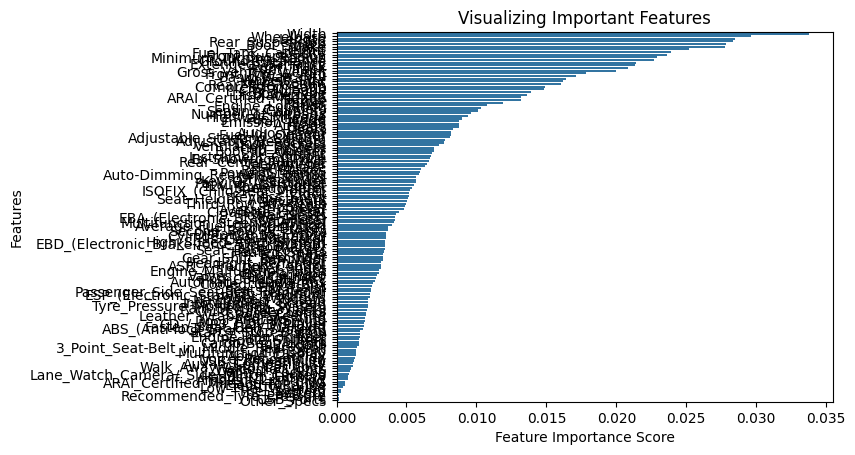

In [62]:
# Creating a seaborn bar plot

sns.barplot(x=feature_scores, y=feature_scores.index)



# Add labels to the graph

plt.xlabel('Feature Importance Score')

plt.ylabel('Features')



# Add title to the graph

plt.title("Visualizing Important Features")



# Visualize the graph

plt.show()

# 17. Build the Random Forest model on selected features

In [63]:
# declare feature vector and target variable

X = dataset.drop(["Displacement","Cylinders"], axis=1)

y = dataset["Cylinders"]

In [82]:
# split data into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)

In [83]:
# encode categorical variables with ordinal encoding

encoder = ce.OrdinalEncoder(cols=["Cylinder_Configuration",	"Emission_Norm",	"Engine_Location",	"Leather_Wrapped_Steering"	,"Automatic_Headlamps",	"Engine_Type"])


X_train = encoder.fit_transform(X_train)

X_test = encoder.transform(X_test)

In [84]:
X_train.dtypes

Make                    object
Model                   object
Variant                 object
Ex-Showroom_Price       object
Valves_Per_Cylinder    float64
                        ...   
USB_Ports              float64
Heads-Up_Display        object
Welcome_Lights          object
Battery                 object
Electric_Range          object
Length: 138, dtype: object

In [85]:
import category_encoders as ce

cat_cols = X_train.select_dtypes(include=['object']).columns

encoder = ce.OrdinalEncoder(cols=cat_cols)

X_train = encoder.fit_transform(X_train)
X_test = encoder.transform(X_test)

In [86]:
# instantiate the classifier with n_estimators = 100

clf = RandomForestClassifier(random_state=0)



# fit the model to the training set

clf.fit(X_train, y_train)


# Predict on the test set results

y_pred = clf.predict(X_test)



# Check accuracy score 

print('Model accuracy score with doors variable removed : {0:0.4f}'. format(accuracy_score(y_test, y_pred)))

ValueError: Input y contains NaN.